<a href="https://colab.research.google.com/github/parulpandey0705-boop/energy-consumption-analysis/blob/main/energy_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Option 1: Manual Upload

YouYou can manually upload files by clicking the 'Files' icon (folder icon) on the left sidebar, then click on the 'Upload to session storage' icon (file with an arrow pointing up). Select your `hourlyLoadDataIndia.xlsx` file from your local machine.

### Option 2: Programmatic Upload

Alternatively, you can upload the file programmatically using `files.upload()`:

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Save the uploaded file to the /content directory for easy access
  with open(f'/content/{fn}', 'wb') as f:
      f.write(uploaded[fn])

Saving hourlyLoadDataIndia.xlsx to hourlyLoadDataIndia.xlsx
User uploaded file "hourlyLoadDataIndia.xlsx" with length 3304613 bytes


(46728, 7)
             datetime  National Hourly Demand  Northen Region Hourly Demand  \
0 2019-01-01 00:00:00               118690.67                      33692.02   
1 2019-01-01 01:00:00               116029.23                      32534.39   
2 2019-01-01 02:00:00               114044.14                      31730.37   
3 2019-01-01 03:00:00               113648.97                      31529.25   
4 2019-01-01 04:00:00               116290.05                      32406.61   

   Western Region Hourly Demand  Eastern Region Hourly Demand  \
0                      38522.22                      13128.89   
1                      38071.09                      12737.53   
2                      37680.10                      12387.36   
3                      37747.37                      12301.12   
4                      38101.80                      12479.13   

   Southern Region Hourly Demand  North-Eastern Region Hourly Demand  
0                       31681.83                    

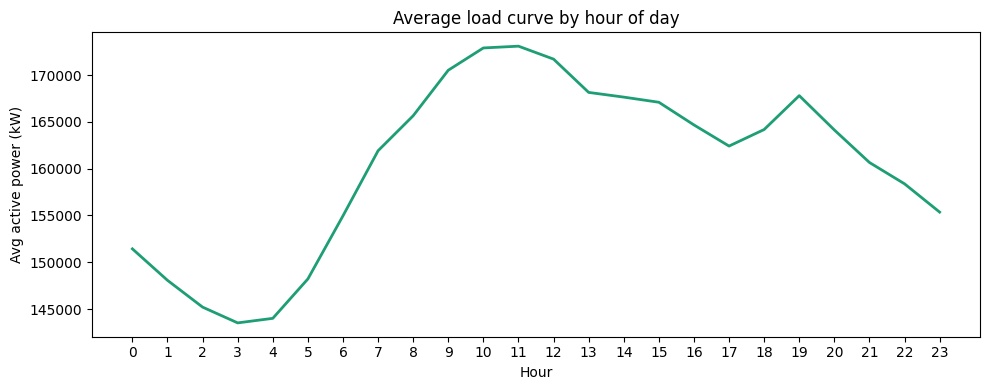

In [ ]:
import pandas as pd
import io
import matplotlib.pyplot as plt

df = pd.read_excel(io.BytesIO(uploaded['hourlyLoadDataIndia.xlsx']))
print(df.shape)
print(df.head())

# Create 'Date' and 'Hour' columns required for the plot
df['Date'] = pd.to_datetime(df['datetime'], dayfirst=True)
df['Hour'] = df['Date'].dt.hour

# Calculate and plot the average load curve by hour of day
hourly = df.groupby('Hour')['National Hourly Demand'].mean()
plt.figure(figsize=(10, 4))
plt.plot(hourly.index, hourly.values, color='#1D9E75', linewidth=2)
plt.title('Average load curve by hour of day')
plt.xlabel('Hour')
plt.ylabel('Avg active power (kW)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel(io.BytesIO(uploaded['hourlyLoadDataIndia.xlsx']))
print(df.shape)         # How many rows and columns?
print(df.dtypes)        # Column data types
print(df.isnull().sum())  # Missing values per column
print(df.describe())    # Min, max, mean of numeric cols
df.head(10)

(46728, 7)
datetime                              datetime64[ns]
National Hourly Demand                       float64
Northen Region Hourly Demand                 float64
Western Region Hourly Demand                 float64
Eastern Region Hourly Demand                 float64
Southern Region Hourly Demand                float64
North-Eastern Region Hourly Demand           float64
dtype: object
datetime                              0
National Hourly Demand                0
Northen Region Hourly Demand          0
Western Region Hourly Demand          0
Eastern Region Hourly Demand          0
Southern Region Hourly Demand         0
North-Eastern Region Hourly Demand    0
dtype: int64
                            datetime  National Hourly Demand  \
count                          46728            46728.000000   
mean   2021-08-31 11:29:59.999999744           160487.065667   
min              2019-01-01 00:00:00            95336.560000   
25%              2020-05-01 17:45:00           145338.7

,datetime,National Hourly Demand,Northen Region Hourly Demand,Western Region Hourly Demand,Eastern Region Hourly Demand,Southern Region Hourly Demand,North-Eastern Region Hourly Demand
0,2019-01-01 00:00:00,118690.67,33692.02,38522.22,13128.89,31681.83,1665.72
1,2019-01-01 01:00:00,116029.23,32534.39,38071.09,12737.53,31129.97,1556.24
2,2019-01-01 02:00:00,114044.14,31730.37,37680.10,12387.36,30760.87,1485.44
3,2019-01-01 03:00:00,113648.97,31529.25,37747.37,12301.12,30616.27,1454.96
4,2019-01-01 04:00:00,116290.05,32406.61,38101.80,12479.13,31839.38,1463.14
5,2019-01-01 05:00:00,124434.00,36376.37,39757.78,13252.46,33551.13,1496.27
6,2019-01-01 06:00:00,136638.94,41588.16,43250.17,14170.40,36059.11,1571.10
7,2019-01-01 07:00:00,147992.72,43703.11,47735.68,15103.72,39695.93,1754.27
8,2019-01-01 08:00:00,153580.44,44815.75,49976.75,15329.48,41690.19,1768.27
9,2019-01-01 09:00:00,156556.18,45662.13,51698.61,15247.92,42244.94,1702.59


In [ ]:
df = pd.read_excel(io.BytesIO(uploaded['hourlyLoadDataIndia.xlsx']))
print(df.shape)         # How many rows and columns?
print(df.dtypes)        # Column data types
print(df.isnull().sum())  # Missing values per column
print(df.describe())    # Min, max, mean of numeric cols
df.head(10)
df['Date'] = pd.to_datetime(df['datetime'], dayfirst=True)
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Hour']  = df['Date'].dt.hour

df.ffill(inplace=True)

mean = df['National Hourly Demand'].mean()
std  = df['National Hourly Demand'].std()
df   = df[abs(df['National Hourly Demand'] - mean) < 3 * std]

print(f"Rows after cleaning: {len(df)}")

(46728, 7)
datetime                              datetime64[ns]
National Hourly Demand                       float64
Northen Region Hourly Demand                 float64
Western Region Hourly Demand                 float64
Eastern Region Hourly Demand                 float64
Southern Region Hourly Demand                float64
North-Eastern Region Hourly Demand           float64
dtype: object
datetime                              0
National Hourly Demand                0
Northen Region Hourly Demand          0
Western Region Hourly Demand          0
Eastern Region Hourly Demand          0
Southern Region Hourly Demand         0
North-Eastern Region Hourly Demand    0
dtype: int64
                            datetime  National Hourly Demand  \
count                          46728            46728.000000   
mean   2021-08-31 11:29:59.999999744           160487.065667   
min              2019-01-01 00:00:00            95336.560000   
25%              2020-05-01 17:45:00           145338.7

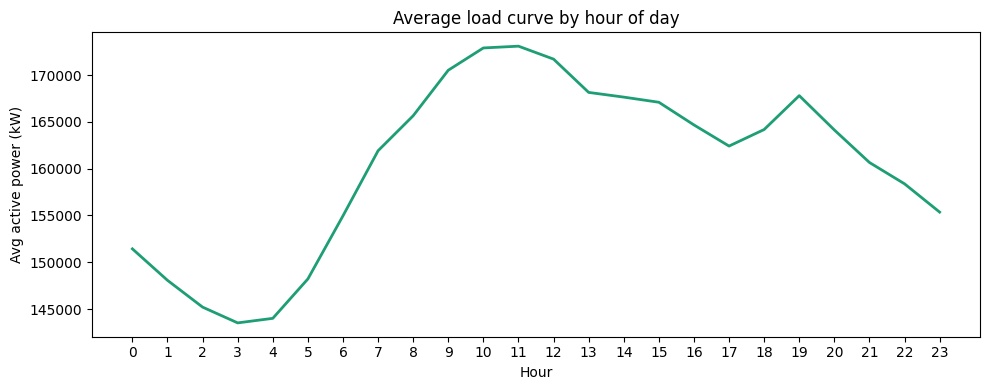

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

hourly = df.groupby('Hour')['National Hourly Demand'].mean()
plt.figure(figsize=(10, 4))
plt.plot(hourly.index, hourly.values, color='#1D9E75', linewidth=2)
plt.title('Average load curve by hour of day')
plt.xlabel('Hour')
plt.ylabel('Avg active power (kW)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

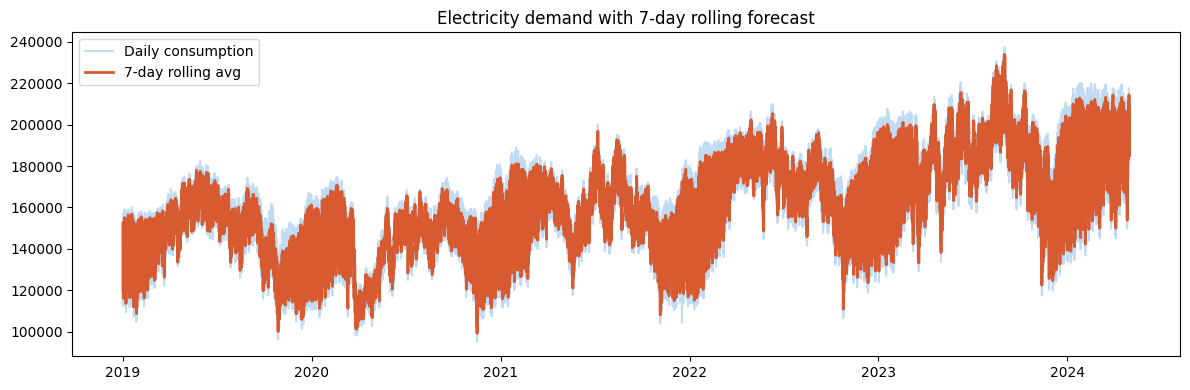

In [ ]:
daily = df.groupby('Date')['National Hourly Demand'].sum().reset_index()
daily.columns = ['Date', 'Total_power']

daily['7day_avg'] = daily['Total_power'].rolling(window=7).mean()

plt.figure(figsize=(12, 4))
plt.plot(daily['Date'], daily['Total_power'],
         alpha=0.3, color='#378ADD', label='Daily consumption')
plt.plot(daily['Date'], daily['7day_avg'],
         color='#D85A30', linewidth=2, label='7-day rolling avg')
plt.legend()
plt.title('Electricity demand with 7-day rolling forecast')
plt.tight_layout()
plt.show()

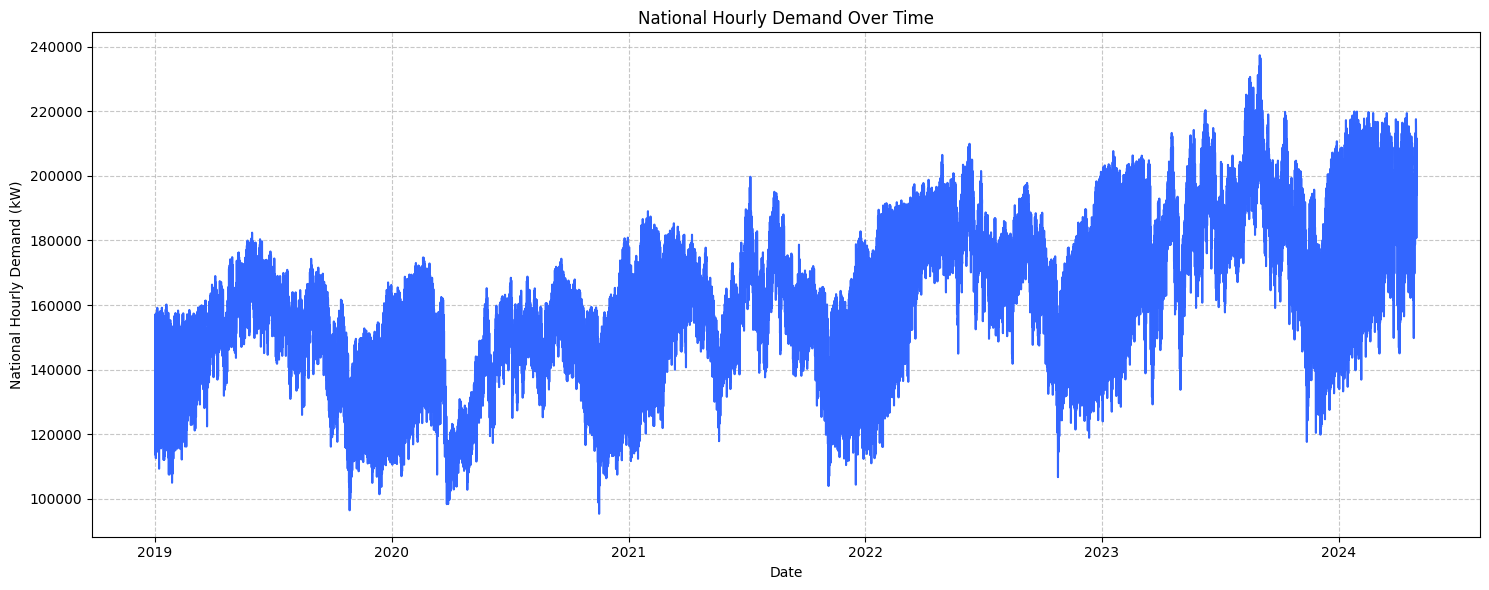

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['National Hourly Demand'], color='#3366ff')
plt.title('National Hourly Demand Over Time')
plt.xlabel('Date')
plt.ylabel('National Hourly Demand (kW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Save the cleaned DataFrame to an Excel file
df.to_excel('hourlyLoadDataIndia_cleaned.xlsx', index=False)
print('Cleaned data saved to hourlyLoadDataIndia_cleaned.xlsx')


Cleaned data saved to hourlyLoadDataIndia_cleaned.xlsx


You can now download `hourlyLoadDataIndia_cleaned.xlsx` from the 'Files' section on the left sidebar.